**1. Demonstrate JavaScript's Single-Threaded Nature**

Question:

Write an example to show that JavaScript is **single-threaded** by creating two competing tasks, one that blocks the event loop and another async function that waits for a promise


```
console.log("Start");

// Async task (Promise)
setTimeout(() => {
  console.log("Async task done!");
}, 0);

// Blocking task (heavy loop)
for(let i = 0; let i < 1000000; i++){}

console.log("Blocking task finished!");

```

**Output**

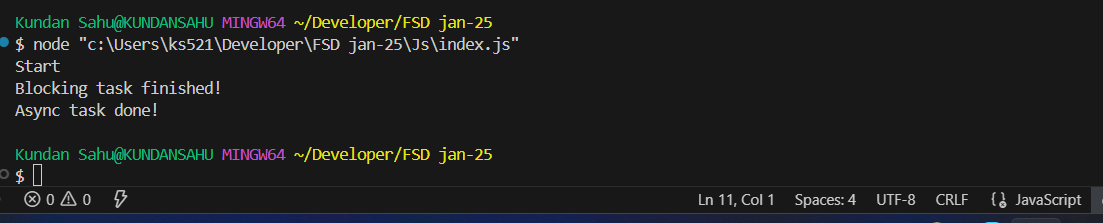

**2. Why Does JavaScript Not Execute Asynchronously by Default?**

 Question:

 JavaScript is often called synchronous and single-threaded, yet it handles asynchronous tasks like AJAX requests, timers, and event listeners

 a.  Explain why JavaScript does not execute asynchronously by default

 JavaScript does not execute asynchronously by default because it is designed to be a synchronous and single-threaded language. This means it executes one line of code at a time, in order. There are several important reasons for this design:

**1. Simplicity and Predictability**

* If JavaScript were asynchronous by default, every line of code could run in an unpredictable order.
But synchronous execution ensures:

  * Code runs from top to bottom

  * The output is predictable

  * Debugging becomes easier

This makes JavaScript simpler to learn and use.

**2. Single-Threaded Execution Model**

* JavaScript uses a single thread, which means only one task can run at a time.
If everything were asynchronous, it would create many race conditions and make the entire execution flow difficult to manage on a single thread.


**3. Asynchronous Tasks Are Handled by the Browser/Node.js, Not by JavaScript**

* JavaScript itself cannot perform asynchronous operations.
Instead, Web APIs (like setTimeout, fetch, event listeners, etc.) handle async work in the background.

* JavaScript only:

  * Sends async tasks to Web APIs

  * Waits for them to complete

  * Uses the Event Loop to run the callback later

Because async behavior is provided by the environment, not by JavaScript itself, the core language remains synchronous.

**4. Performance Considerations**

* Running everything asynchronously would require:

  * Promises for every operation

  * Extra memory

  * Complex scheduling

This would slow down simple programs.
So JavaScript uses async only when needed, which keeps performance efficient.

**5. Historical Design Choice**

* When JavaScript was created in 1995, the language was intended for small browser interactions like form validation.
Synchronous execution was the best and simplest choice at that time.

 b. Write a code snippet to prove that JavaScript is inherently synchronous

 ```

 console.log("A");

setTimeout(() => {
  console.log("B");
}, 0);

console.log("C");
```

**Output**

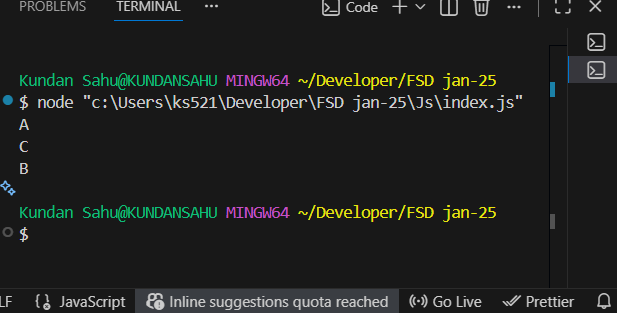



**3.Chaining Promises with setTimeout**

Modify the delay function to **chain multiple** promises so that three messages are logged **in sequence with delays**


```
function delay(ms, message) {
  return new Promise((resolve) => {
    setTimeout(() => {
      console.log(message);
      resolve();
    }, ms);
  });
}
//chaining promise
delay(1000, "Message 1 after 1 second")
  .then(() => delay(2000, "Message 2 after 2 seconds"))
  .then(() => delay(1500, "Message 3 after 1.5 seconds"));
```
**Output**

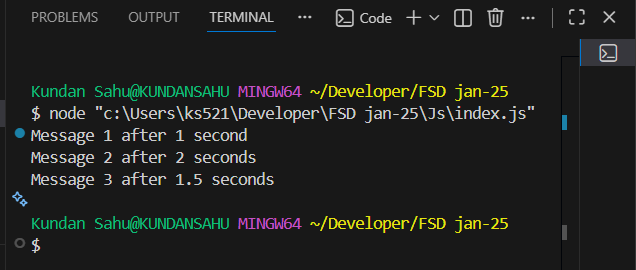

**4.What are the different states of a Promise, and how do they transition?**

A JavaScript Promise has three states: **pending**, **fulfilled**, and **rejected.** It starts in the pending state, and transitions to either fulfilled (success) or rejected (failure) once the asynchronous operation completes, at which point it becomes "settled".

**States**

* **Pending:** The initial state. The operation is still in progress, and the promise has neither been fulfilled nor rejected yet.
* **Fulfilled (or Resolved):** The operation completed successfully. The promise is now settled and has a resulting value, which can be handled using the .then() method.
* **Rejected:** The operation failed. The promise is now settled and has a reason for the failure (typically an error), which can be handled using the .catch() method.

**Transitions**

* A promise can only transition from pending to one of the other two states.
* It will transition to fulfilled if the asynchronous operation succeeds and the resolve() function is called.
* It will transition to rejected if the operation fails and the reject() function is called.
* Once a promise is either fulfilled or rejected, it is considered "settled" and cannot change its state again.

**5. How does the JavaScript event loop handle Promises differently from setTimeout?**

The JavaScript event loop handles Promises and setTimeout differently due to their categorization into microtasks and macrotasks, respectively. This distinction dictates their priority and execution order within the event loop.

**Macrotasks (e.g., setTimeout, setInterval, I/O operations):**
* When setTimeout is called, its callback is placed in the macrotask queue (also known as the task queue or callback queue) after the specified delay.
* The event loop processes macrotasks one by one in each iteration. After completing the current execution stack, it checks the macrotask queue and executes the oldest available macrotask.
* Each macrotask can potentially schedule more macrotasks or microtasks.

**Microtasks (e.g., Promises' .then(), .catch(), .finally(), queueMicrotask):**
* When a Promise resolves or rejects, its associated .then(), .catch(), or .finally() callbacks are placed in the microtask queue.
* The event loop gives the microtask queue a higher priority than the macrotask queue.
* Crucially, after the current execution stack is empty, the event loop completely drains the microtask queue before moving on to process the next macrotask in the macrotask queue. This means all pending microtasks will execute before any pending macrotasks.

 Promises' callbacks (microtasks) will always execute before setTimeout callbacks (macrotasks) if they are ready in the same event loop cycle, even if the setTimeout has a 0ms delay. This priority ensures that reactions to Promise resolutions are handled more promptly.

 **Example**

 ```
 console.log("Start");

setTimeout(() => {
  console.log("Timeout");
}, 0);

Promise.resolve().then(() => {
  console.log("Promise");
});

console.log("End");

 ```

 **Output**


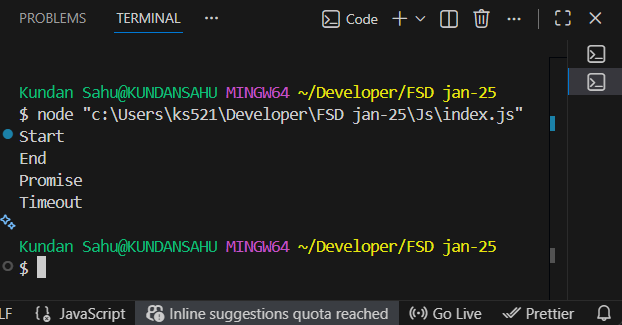
